# Assignment: Video editing with DMD

---
## 1. Instructions

Alongside this assignment you will find a black-and-white video called `formula1.mp4`. The video shows Formula 1 cars driving around a corner in the Monte Carlo circuit.

### 1.1 Your task

Interpret the video as a dynamical system where images follow each other in time. Using any of the techniques you learned in the course, create:

1. A video showing (approximately) only the moving cars
2. A video showing (approximately) only the stationary background

Keep your work organized in a Jupyter Notebook. Make sure your notebook is well organized, with appropriate sections, and with text to explain your work.

### 1.2 What you have to submit

Work in your assigned group to solve the assignment. Each group must submit the following on StudOn by the stated deadline:

1. The videos you produced.
2. A Jupyter Notebook with your solution.
3. The PDF of the slides you will use to present your results. (You do not need to embed videos in the presentation, but the videos you use in the actual presentation must be the same you submit.)

**Instructions for the final presentations:**
* Assignment presentations will take place according the schedule on StudOn (last few weeks of the semester). 
* Each group should plan a **10 min** presentation explaining the solution method and discussing the results. 
* Each group member must give part of the presentation, with time divided as equally as possible among group members.

### 1.3 Creating the output videos

To create the output videos, save individual frames as images with the name `frame_0000.png`, `frame_0001.png`, `frame_0002.png`, etc. in the folders `bg-img` (for the background) and `fg-img` (for the moving cars in the foreground). These are provided along with the assignment. You may then combine these images into a video using the following functions, which are provided in the *Useful Functions* section below:

1. `ImportMovie`: A function to import a video file into Python
2. `mat2gray`: A function to transform a matrix with arbitrary values into a grayscale image
3. `CreateVideo`: A function to create a video from a sequence of PNG images

Of course, you can use your own functions if you prefer.

**Note:** To use the function `ImportMovie`, you must install the Python package [opencv-python](https://pypi.org/project/opencv-python/). You should be able to do this from a terminal window by running the following commands:

```
$ pip install --upgrade pip
$ pip install opencv-python
```

If you run into trouble, please ask for help during the surgery classes or seek advice on the internet (it usually works!)

---
## 2 Useful Functions

We import two necessary packages.

In [1]:
import numpy as np
import cv2

### 2.1 ImportMovie

The following function imports a movie into Python.

**Input:**  A string `fname`, specifying the video file to import. The string may include the path to the video file

**Outputs:** A three-dimensional array `movie` such that `movie[k,:,:]` contains the kth frame of the video, and a scalar `FrameRate` giving the number of frames per second in the video. The shape of `movie` is `(NumberOfFrames, Height, Width)`, where `NumberOfFrames` is the number of frames (images) in the video, while `Height` and `Width` are the height and width (in pixels) of each frame.

**Example:** Call this function as

replacing the file name with the video file you want to load.

In [2]:
# First a useful function to convert RGB images to grayscale
def rgb2gray(rgb):
        return np.dot(rgb[...,:3], [0.299, 0.587, 0.114])

# Then, the main movie import function
def ImportMovie(fname):
    # Open video
    vidcap = cv2.VideoCapture(fname)
    FrameRate = vidcap.get(cv2.CAP_PROP_FPS)
    # Import first video frame
    success,image = vidcap.read()
    count = 0
    success = True
    movie = []
    # Import other frames until end of video
    while success:
        movie.append(rgb2gray(image))
        success, image = vidcap.read()
        count += 1
    # Convert to array
    movie = np.array(movie)
    # Display some summary information
    print("==========================================")
    print("           Video Import Summary           ")
    print("------------------------------------------")
    print("   Imported movie: ", fname)
    print(" Frames extracted: ", count)
    print("Frames per second: ", FrameRate)
    print("      data shape = ", movie.shape)
    print("==========================================")
    return movie, FrameRate



### 2.2 mat2gray

The following function takes in a matrix (two-dimensional array) `image` and turns it into a matrix that can be plotted as a grayscale image.

**Example:** Call this function as

where `image` is the matrix you want to plot in grayscale.

In [3]:
def mat2gray(image):
    out_min = np.min(image[:])
    out_max = np.max(image[:])
    idx = np.logical_and(image > out_min, image < out_max)
    image[image <= out_min] = 0;
    image[image >= out_max] = 255;
    image[idx] = ( 255/(out_max - out_min) ) * (image[idx] - out_min)
    return image

### 2.3 CreateVideo

The following function creates a video called `video_name` in the current directory by concatenating the .png images in the folder specified by the input `image_folder`.

In [4]:
import os
def CreateVideo(video_name, image_folder):
    # image_folder = "."
    # video_name = "f1slow.avi"
    images = [img for img in os.listdir(image_folder) if img.endswith(".png")]
    images = np.sort(images)
    frame = cv2.imread(os.path.join(image_folder, images[0]))
    height, width, layers = frame.shape
    video = cv2.VideoWriter(video_name, cv2.VideoWriter_fourcc(*"mp4v"), 60, (width, height)) 
    for image in images:
        video.write(cv2.imread(os.path.join(image_folder, image)))
    cv2.destroyAllWindows()
    video.release()

---
## 3. Solution

In [5]:
# Type your solution here
# Do not forget to format your notebook nicely, using sections,
# subsections, text blocks to explain what you are doing between
# blocks of code, and so on.

movie, FrameRate = ImportMovie("./formula1.mp4")


           Video Import Summary           
------------------------------------------
   Imported movie:  ./formula1.mp4
 Frames extracted:  758
Frames per second:  59.94005994005994
      data shape =  (758, 236, 420)


In [11]:
movie.shape

(758, 236, 420)

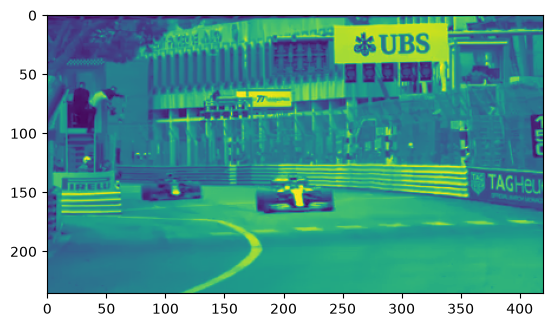

In [7]:
import matplotlib.pyplot as plt
plt.imshow(mat2gray(movie[10]))

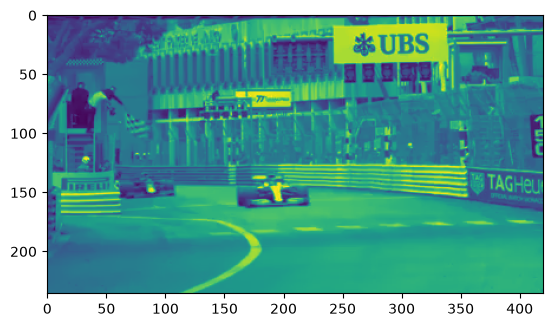

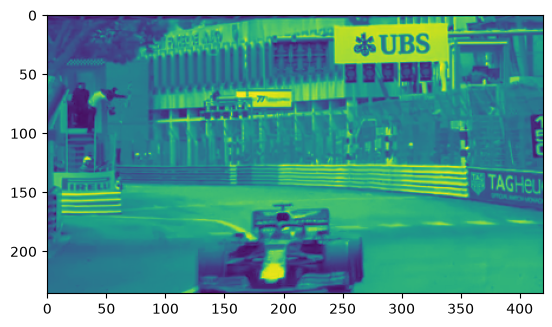

In [8]:
plt.imshow(mat2gray(movie[0]))
plt.show()
plt.imshow(mat2gray(movie[100]))

In [ ]:

frames, h, w = movie.shape

X = movie.reshape(frames, h * w).T

print(f"X shape: {X.shape}")
print(frames)

X1 = X[:, :-1]
X2 = X[:, 1:]

# SVD Computation

U, S, Vh = np.linalg.svd(X1, full_matrices=False)

X shape: (99120, 758)
758


In [22]:
energy = np.cumsum(S) / np.sum(S)
r = np.searchsorted(energy, 0.9)

In [23]:
r

np.int64(99)

In [24]:
V = Vh.conj().T

U_r = U[:, :r]
S_r = S[:r]
V_r = V[:, :r]

Ar = U_r.conj().T @ X2 @ V_r @ np.diag(1/S_r)

In [25]:
Ar

array([[ 1.00002487e+00, -9.68739627e-04,  3.09801914e-04, ...,
         5.61536486e-03,  4.94055882e-03, -8.91845922e-03],
       [-2.84564451e-04,  9.97431007e-01,  2.23005804e-02, ...,
        -3.57622931e-02, -4.76443281e-02,  8.35040248e-02],
       [-1.03301292e-04, -7.21383640e-03,  9.93546236e-01, ...,
        -4.16524779e-02, -2.51821213e-05,  5.90871662e-02],
       ...,
       [-6.05502529e-06, -3.25283058e-05,  5.01837827e-06, ...,
         5.28234934e-01,  4.49188908e-03, -1.58107796e-02],
       [-1.27658208e-05, -5.18199011e-05, -1.99930404e-04, ...,
         8.62529875e-02,  3.67253229e-01,  1.01789208e-02],
       [ 2.18709847e-05,  1.44105141e-04,  2.42621865e-04, ...,
        -1.27809555e-01, -3.81201510e-02,  5.75368757e-01]],
      shape=(99, 99))